In [1]:
import torch
import torch.nn as nn
import pandas as pd
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 1. Define the Dictionary for Class Names
# ---------------------------------------------------------
classes = { 
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)', 
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)', 
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)', 
    9: 'No passing', 10: 'No passing veh over 3.5 tons', 11: 'Right-of-way at intersection', 
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles', 
    16: 'Veh > 3.5 tons prohibited', 17: 'No entry', 18: 'General caution', 
    19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve', 
    22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on the right', 
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing', 
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing', 
    32: 'End speed + passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead', 
    35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left', 
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory', 41: 'End of no passing', 
    42: 'End no passing veh > 3.5 tons' 
}

In [2]:
# ---------------------------------------------------------
# 2. Recreate the Network Architecture
# ---------------------------------------------------------
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(TrafficSignCNN, self).__init__()
        self.features = nn.Sequential(
            # Conv Layer 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Conv Layer 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Conv Layer 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # If input is 32x32:
        # After Pool 1: 16x16
        # After Pool 2: 8x8
        # After Pool 3: 4x4
        # Flattened: 256 channels * 4 * 4 = 4096
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), 
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [3]:
# ---------------------------------------------------------
# 3. Load the Saved Weights
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TrafficSignCNN(num_classes=43)
model.load_state_dict(torch.load('traffic_sign_classifier.pth', map_location=device))
model.to(device)
model.eval() # Set model to evaluation mode (turns off dropout)

print(f"Model loaded successfully on {device}!")

Model loaded successfully on cuda!


In [4]:
# ---------------------------------------------------------
# 4. Prepare the Image Transform Pipeline
# ---------------------------------------------------------
test_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

In [5]:
# ---------------------------------------------------------
# 5. Function to Predict a Custom Image
# ---------------------------------------------------------
def predict_image(image_path):
    if not os.path.exists(image_path):
        print(f"Error: File not found at {image_path}")
        return
        
    # Open image using PIL and ensure it's RGB
    img = Image.open(image_path).convert('RGB')
    
    # Preprocess and add a batch dimension (unsqueeze) -> Shape becomes [1, 3, 32, 32]
    input_tensor = test_transforms(img).unsqueeze(0).to(device)
    
    # Run prediction
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted_class_id = torch.max(probabilities, 1)
        
    class_id = predicted_class_id.item()
    sign_name = classes[class_id]
    
    print(f"Image: {os.path.basename(image_path)}")
    print(f"Prediction: {sign_name} (Class ID: {class_id})")
    print(f"Confidence: {confidence.item() * 100:.2f}%\n")


In [6]:
# ---------------------------------------------------------
# 6. Test it out!
# ---------------------------------------------------------
# Point this to any image inside your Kaggle 'Test' folder or an image from Google
my_test_image = 'data/Test/00000.png' 
predict_image(my_test_image)

Image: 00000.png
Prediction: Veh > 3.5 tons prohibited (Class ID: 16)
Confidence: 99.97%



In [13]:
def plot_confusion_matrix(model, test_loader, device, num_classes=43):
    # 1. Put the model in evaluation mode
    model.eval()
    
    all_preds = []
    all_labels = []
    
    # 2. Turn off gradients for testing
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Get the index of the highest probability class
            _, predictions = torch.max(outputs, 1)
            
            # Move data back to CPU and convert to lists
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 3. Calculate the Confusion Matrix
    # FIX: Explicitly set labels=list(range(num_classes)) so it stays 43x43
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    
    # 4. Plotting the Matrix
    plt.figure(figsize=(18, 14)) # Slightly larger to fit text labels cleanly
    
    # Optional performance boost: Use your 'classes' dictionary for clear axis labels
    class_names = [classes[i] for i in range(num_classes)]
    
    sns.heatmap(
        cm, 
        annot=True, 
        cmap='Blues', 
        fmt='d',
        xticklabels=class_names,
        yticklabels=class_names
    )
    
    plt.title('Traffic Sign Confusion Matrix', fontsize=16)
    plt.ylabel('Actual True Sign (Ground Truth)', fontsize=12)
    plt.xlabel('What the Model Predicted', fontsize=12)
    
    plt.xticks(rotation=90) # Rotate text labels so they don't overlap
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

In [11]:
test_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

test_dataset = ImageFolder(root='data/Test_Structured', transform=test_transforms)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

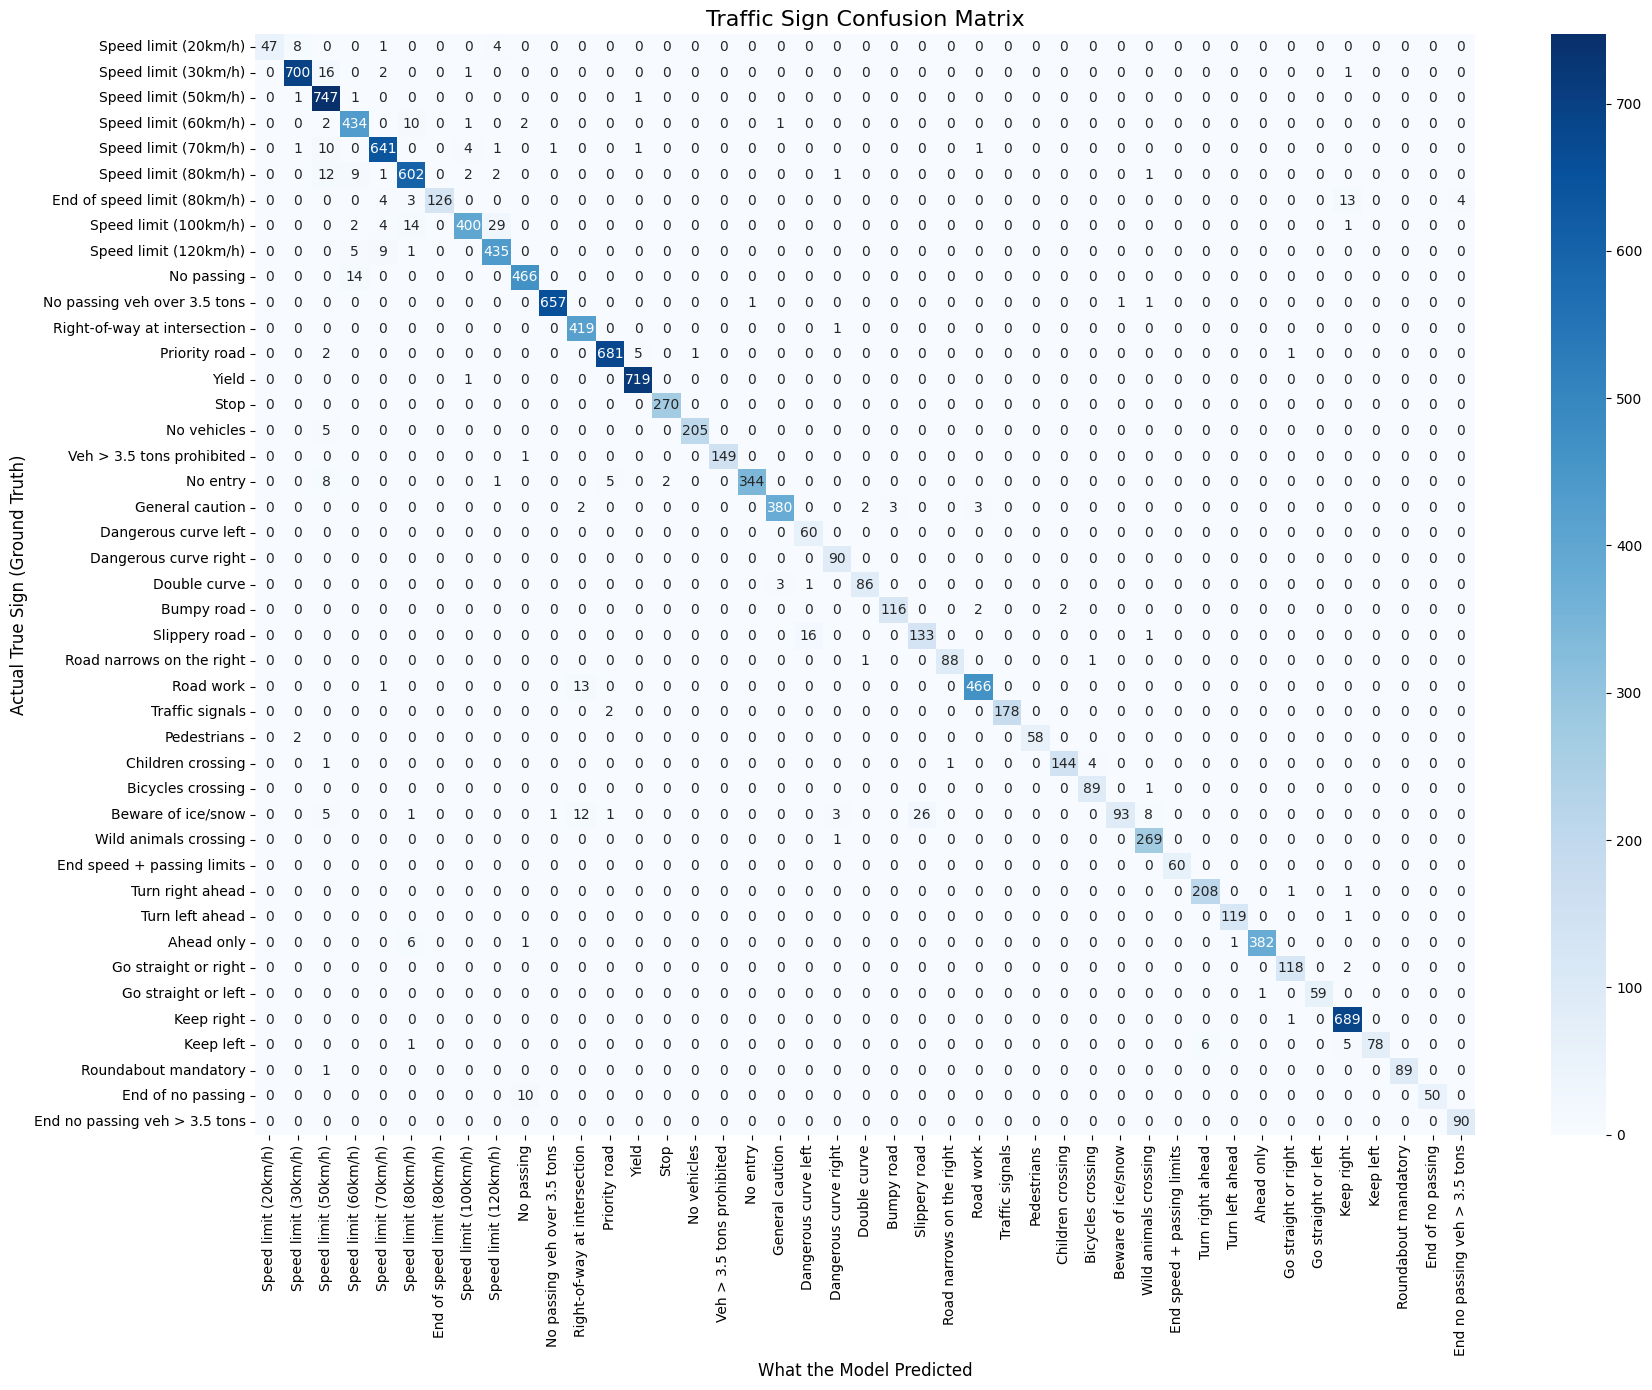

In [14]:
# Set your device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Run the confusion matrix!
plot_confusion_matrix(model, test_loader, device, num_classes=43)